In [ ]:

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

DATA_PATH = Path("Datasets and splits/Freegait/FreeGait/FreeGait/native_csv_export/kp3d_native_wide.csv")
assert DATA_PATH.exists(), f"Dataset not found at {DATA_PATH}"

import randomf
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:

# ==================== CONFIG ====================
WINDOW_SIZE = 29
OVERLAP = 14
TEST_RATIO = 0.20
VAL_RATIO  = 0.20

BATCH_SIZE = 64
EPOCHS = 1000
LEARNING_RATE = 1e-3

MAX_SESSIONS = None  # None = all sessions
# ================================================


In [ ]:
import numpy as np

def fix_missdetected_joints(group, max_gap=500000, min_dup=4):
    #max gap for one second in this work because fps is 6
    """
    If, within the same frame, >= min_dup joints have EXACTLY the same (x,y,z),
    mark those joints as NaN and fill over time using linear interpolation.
    """
    joints = [
    "head", "neck", "spine3",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
 ]

    #copy data frame 
    group = group.copy()
    #Build joint coordinate column names
    cols = [f"joint_{j}_{a}" for j in joints for a in "xyz"]
    #Convert to numpy and reshape to (T,J,3) where T is number of frames, J is number of joints
    arr = group[cols].to_numpy(float).reshape(len(group), len(joints), 3)
    #Mask for missdetected joints
    bad = np.zeros((len(group), len(joints)), dtype=bool)
    #Loop through each frame and find duplicates
    for t in range(len(group)):
        frame = arr[t]  # (J,3)
        #Ignore joints that already have NaNs in case it got used by CLS 
        valid = ~np.isnan(frame).any(axis=1)
        if valid.sum() < 2:
            continue

        # Find exact duplicate 3D coordinates in that frame
        uniq, inv, counts = np.unique(frame[valid], axis=0,
                                      return_inverse=True, return_counts=True)
        #Keep only coordinates repeated at least min_dup times
        dup_ids = np.where(counts >= min_dup)[0]
        if dup_ids.size == 0:
            continue
        #Mark those joints as bad
        dup_valid_mask = np.isin(inv, dup_ids)
        joint_idx = np.where(valid)[0][dup_valid_mask]
        joint_idx = joint_idx[joint_idx != pelvis] # but never the pelvis
        bad[t, joint_idx] = True

    # Set duplicated joints to NaN (all 3 axes)
    arr[bad] = np.nan
    group.loc[:, cols] = arr.reshape(len(group), -1)

    # Fill from previous + next frames
    group.loc[:, cols] = (
        group.loc[:, cols]
             .interpolate(method="linear", limit=max_gap, limit_direction="both")
             .ffill(limit=max_gap)
             .bfill(limit=max_gap)
    )

    return group


In [4]:
def Torso_centering(group, joints_col):
    for axis in "xyz":
        cols = [c for c in joints_col if c.endswith(f"_{axis}")]
        torso_col = f"joint_torso_{axis}"
        cols_wo_torso = [c for c in cols if c != torso_col]

        before = group[cols_wo_torso].to_numpy(copy=True)
        group.loc[:, cols] = group.loc[:, cols].sub(group[torso_col], axis=0)
        after = group[cols_wo_torso].to_numpy()

        became_zero = (~np.isclose(before, 0.0, atol=1e-6)) & (np.isclose(after, 0.0, atol=1e-6))
        per_col = became_zero.sum(axis=0)

        for col, cnt in zip(cols_wo_torso, per_col):
            if cnt > 0:
                print(f"{col}: {cnt} values became zero due to centering")

    return group



In [5]:
import numpy as np

def make_windows(seq, label, window_size, step, pad_mode="edge"):
    """
    pad_mode:
      - "edge": repeat last frame 
      - "zero": pad with zeros
    """
    out_X, out_y = [], []
    T = len(seq)

    if T == 0:
        return out_X, out_y

    # If too short: pad and return exactly 1 window
    if T < window_size:
        seq = np.asarray(seq)
        pad_len = window_size - T

        if pad_mode == "edge":
            pad = np.repeat(seq[-1][None, :], pad_len, axis=0)
        elif pad_mode == "zero":
            pad = np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)
        else:
            raise ValueError("pad_mode must be 'edge' or 'zero'")

        win = np.vstack([seq, pad])
        out_X.append(win)
        out_y.append(label)
        return out_X, out_y

    # Normal sliding windows
    for start in range(0, T - window_size + 1, step):
        out_X.append(seq[start:start + window_size])
        out_y.append(label)

    return out_X, out_y


In [ ]:

# Optional: padded windowing 
def make_windows_padded(seq, label, window_size, step, pad_mode="edge"):
    """
    Like make_windows, but if len(seq) < window_size it pads and returns exactly 1 window.
    """
    out_X, out_y = [], []
    seq = np.asarray(seq)
    T = len(seq)

    if T == 0:
        return out_X, out_y

    if T < window_size:
        pad_len = window_size - T
        if pad_mode == "edge":
            pad = np.repeat(seq[-1][None, :], pad_len, axis=0)
        elif pad_mode == "zero":
            pad = np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)
        else:
            raise ValueError("pad_mode must be 'edge' or 'zero'")
        win = np.vstack([seq, pad])
        out_X.append(win)
        out_y.append(label)
        return out_X, out_y

    for start in range(0, T - window_size + 1, step):
        out_X.append(seq[start:start + window_size])
        out_y.append(label)

    return out_X, out_y

In [7]:
import numpy as np

def preprocess_features_split(
    df,
    window_size,
    overlap,
    test_session_ratio=0.20,
    val_session_ratio=0.16,   
    seed=42,
    fps=10,
    fc=2.5,
    min_seqs_per_person=30,          # keep only persons with >= this many eligible sessions
    max_seqs_per_person=None,       # optional cap per person (helps balancing)
    remove_trajectory=True,         # pelvis-center before velocity/features
    use_padded_windows=False,       # if True, use make_windows_padded instead of make_windows
):
    """
    

    Returns:
      X_train: (Ntr, window_size, F)
      y_train: (Ntr,)
      X_test:  (Nts, window_size, F)
      y_test:  (Nts,)
      feat_cols: list[str]
    """

    # -------------------------------
    # 0) session_id
    # -------------------------------
    if "session_id" not in df.columns:
        df = df.copy()
        df["session_id"] = (
            df["person"].astype(str) + "-" +
            df["device"].astype(str) + "-" +
            df["sequence"].astype(str)
        )

    # -------------------------------
    # 1) columns / params
    # -------------------------------
    joint_cols = [
        c for c in df.columns
        if c.startswith("joint_") and c.endswith(("_x", "_y", "_z"))
    ]

    step = max(1, window_size - overlap)
    rng = np.random.default_rng(seed)

    # -------------------------------
    # 2) Build per-session feature sequences
    # -------------------------------
    sessions_by_person = {}  # person -> list of (session_id, feats[T,F])
    feat_cols = joint_cols
   
    grouped = df.groupby(["person", "session_id"], sort=False)

    for (person, session_id), group in grouped:
        group = group.sort_values("frame").reset_index(drop=True).copy()
        

        group = group.dropna(subset=joint_cols).reset_index(drop=True)
        if len(group) == 0:
            continue

        # optional: remove trajectory by pelvis-centering each frame
        if remove_trajectory:
            for ax in ("x", "y", "z"):
                pel = group[f"joint_pelvis_{ax}"].to_numpy()
                cols_ax = [c for c in joint_cols if c.endswith(f"_{ax}")]
                group.loc[:, cols_ax] = group.loc[:, cols_ax].to_numpy() - pel[:, None]
 
        feats = group[joint_cols].to_numpy()
        sessions_by_person.setdefault(str(person), []).append((str(session_id), feats))

    # nothing usable
    if feat_cols is None:
        return (
            np.empty((0, window_size, 0), dtype=np.float32),
            np.empty((0,), dtype=object),
            np.empty((0, window_size, 0), dtype=np.float32),
            np.empty((0,), dtype=object),
            [],
        )

    # -------------------------------
    # 3) Split sessions per person -> window samples
    # -------------------------------
    X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
    kept_people = 0
    dropped_people = 0

    win_fn = make_windows_padded if use_padded_windows else make_windows
    
    for person, sess_list in sessions_by_person.items():
        eligible = sess_list[:] if use_padded_windows else [
            (sid, feats) for (sid, feats) in sess_list if len(feats) >= window_size
        ]

        n = len(eligible)
        if n == 0:
            continue

        if n < min_seqs_per_person:
            dropped_people += 1
            continue

        if max_seqs_per_person is not None and n > max_seqs_per_person:
            eligible.sort(key=lambda x: x[0])
            eligible = eligible[:max_seqs_per_person]
            n = len(eligible)

        kept_people += 1

        # deterministic order before random split
        eligible.sort(key=lambda x: x[0])
        perm = rng.permutation(n)

        # choose counts
        n_test = int(np.ceil(n * test_session_ratio))
        n_val  = int(np.ceil(n * val_session_ratio))

        # ensure at least 1 train session
        n_test = max(1, min(n_test, n - 1))

        # only make a val split if there is room (need at least 1 train after test+val)
        if n - n_test <= 1:
            n_val = 0
        else:
            n_val = max(1, min(n_val, n - n_test - 1))

        test_idx = set(perm[:n_test].tolist())
        val_idx  = set(perm[n_test:n_test + n_val].tolist())

        for i, (sid, feats) in enumerate(eligible):
            Xw, yw = win_fn(feats, person, window_size, step)
            if i in test_idx:
                X_test.extend(Xw); y_test.extend(yw)
            elif i in val_idx:
                X_val.extend(Xw); y_val.extend(yw)
            else:
                X_train.extend(Xw); y_train.extend(yw)

    print(f"[split] kept persons={kept_people}, dropped persons={dropped_people}")
    print(f"[split] train windows={len(X_train)}, val windows={len(X_val)}, test windows={len(X_test)}")

    return (
        np.asarray(X_train, dtype=np.float32),
        np.asarray(X_val, dtype=np.float32),
        np.asarray(X_test, dtype=np.float32),
        np.asarray(y_train),
        np.asarray(y_val),
        np.asarray(y_test),
        feat_cols,
    )

In [8]:

import pandas as pd


df = pd.read_csv(DATA_PATH, low_memory=False)


X_train, X_val, X_test, y_train, y_val, y_test, _  = preprocess_features_split(df,WINDOW_SIZE, OVERLAP, min_seqs_per_person=50)
#for debugging
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)
classes = list(le.classes_)
#for debugging
print("Classes:", classes)
#for debugging
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


[split] kept persons=7, dropped persons=613
[split] train windows=278, val windows=72, test windows=85
Train: (278, 29, 72) | Val: (72, 29, 72) | Test: (85, 29, 72)
Classes: [np.str_('1150'), np.str_('1165'), np.str_('1191'), np.str_('1194'), np.str_('1206'), np.str_('1229'), np.str_('1235')]
Train: (278, 29, 72) Val: (72, 29, 72) Test: (85, 29, 72)


In [9]:

class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, W, F) N= 
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        # CNN expects (C, W) where C=features, W=window_size
        return self.X[idx].T, self.y[idx]

train_ds = WindowDataset(X_train, y_train_enc)
val_ds   = WindowDataset(X_val, y_val_enc)
test_ds  = WindowDataset(X_test, y_test_enc)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


In [10]:

class CNN(nn.Module):
    def __init__(self, nfeatures, nclasses):
        super().__init__()
        
        # ===== CONV BLOCK 1 =====
        self.conv1 = nn.Conv1d(nfeatures, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.dropout1 = nn.Dropout(0.3)
        
        # ===== CONV BLOCK 2 =====
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        
        # ===== CONV BLOCK 3 =====
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(0.4)
        
        # Pooling
        self.pool = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        
        # ===== FULLY CONNECTED LAYERS =====
        self.fc1 = nn.LazyLinear(256)     
        self.dropout4 = nn.Dropout(0.5)
        
        self.fc2 = nn.LazyLinear(128)
        self.dropout5 = nn.Dropout(0.5)
        
        self.fc3 = nn.LazyLinear(nclasses) # Output
    
    def forward(self, x):
        # Conv block 1
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.dropout1(x)
        x = self.pool(x)
        
        # Conv block 2
        x = torch.relu(self.bn2(self.conv2(x)))
        
        x = self.pool(x)
        
        # Conv block 3 
        x = torch.relu(self.bn3(self.conv3(x)))
        
        x = self.pool(x)
        
        # Flatten
        x = self.flatten(x)
        
        # FC layer 1
        x = torch.relu(self.fc1(x))
        x = self.dropout4(x)
        
        # FC layer 2
        x = torch.relu(self.fc2(x))
        x = self.dropout5(x)
        
        # Output layer


        return self.fc3(x)
# X_train.shape[M] where m is the feature dimension here xzy in joints 
n_features = X_train.shape[2] 
print("Number of features:", n_features)
n_classes = len(classes)
model = CNN(n_features, n_classes).to(DEVICE)
print(model)


Number of features: 72
CNN(
  (conv1): Conv1d(72, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.4, inplace=False)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): LazyLinear(in_features=0, out_features=256, bias=True)
  (dropout4): Dropout(p=0.5, inplace=False)
  (fc2): LazyLinear(in_features=0, out_features=128, bias=True)
  (dropout5): Dropout(p=0.5, inplace=False)
  (fc3):

logits shape: torch.Size([64, 7])
Class counts: [38 35 54 36 36 40 39]
Class weights: tensor([1.0451, 1.1347, 0.7354, 1.1032, 1.1032, 0.9929, 1.0183],
       device='cuda:0')
Epoch 1 | TrainLoss 1.9744 | ValLoss 1.9483 | ValF1 0.032
Epoch 1/1000 - Val Acc: 0.125 | Val F1: 0.032 | LR: 0.001 | best=0.032 bad_epochs=0 | Conf mean=0.157 (correct=0.157, wrong=0.157)
Epoch 2 | TrainLoss 1.9143 | ValLoss 1.9477 | ValF1 0.032
Epoch 2/1000 - Val Acc: 0.125 | Val F1: 0.032 | LR: 0.001 | best=0.032 bad_epochs=1 | Conf mean=0.154 (correct=0.154, wrong=0.154)
Epoch 3 | TrainLoss 1.8780 | ValLoss 1.9492 | ValF1 0.066
Epoch 3/1000 - Val Acc: 0.139 | Val F1: 0.066 | LR: 0.001 | best=0.066 bad_epochs=0 | Conf mean=0.157 (correct=0.157, wrong=0.157)
Epoch 4 | TrainLoss 1.7773 | ValLoss 1.9520 | ValF1 0.083
Epoch 4/1000 - Val Acc: 0.153 | Val F1: 0.083 | LR: 0.001 | best=0.083 bad_epochs=0 | Conf mean=0.169 (correct=0.169, wrong=0.169)
Epoch 5 | TrainLoss 1.7311 | ValLoss 1.9545 | ValF1 0.032
Epoch 5/100

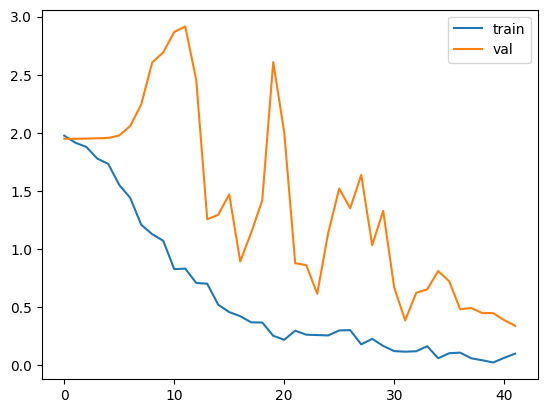

Test Acc: 0.765 | Test BalAcc: 0.770 | TestLoss: 0.6790
Test mean confidence: 0.882
              precision    recall  f1-score   support

           0      0.833     0.909     0.870        11
           1      1.000     0.400     0.571        10
           2      0.882     0.714     0.789        21
           3      0.833     1.000     0.909        10
           4      0.909     0.909     0.909        11
           5      0.458     1.000     0.629        11
           6      1.000     0.455     0.625        11

    accuracy                          0.765        85
   macro avg      0.845     0.770     0.757        85
weighted avg      0.848     0.765     0.762        85

Sample test preds (true, pred, conf):
  0 -> 0  conf=0.993
  0 -> 0  conf=0.994
  0 -> 0  conf=0.983
  0 -> 0  conf=0.991
  0 -> 0  conf=0.980
  0 -> 0  conf=0.976
  0 -> 0  conf=0.836
  0 -> 0  conf=0.882
  0 -> 0  conf=0.819
  0 -> 0  conf=0.972
  0 -> 5  conf=0.661
  1 -> 1  conf=0.759
  1 -> 3  conf=0.570
  1 -> 1

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)

# ---------- sanity check (BEFORE training) ----------
model.eval()
X0, y0 = next(iter(train_loader))
logits0 = model(X0.to(DEVICE))
print("logits shape:", logits0.shape)  # should be (batch_size, n_classes)

# ---------- class weights ----------
num_classes = n_classes
class_counts = np.bincount(y_train_enc, minlength=num_classes)
print(f"Class counts: {class_counts}")

class_weights = class_counts.sum() / (num_classes * class_counts)
class_weights[class_counts == 0] = 0.0  # safety if any class missing in train
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5
)

# ---------- evaluation---------
def evaluate(loader):
    
    model.eval(); y_true=[]; y_pred=[]; y_conf=[]; val_loss = 0.0; n = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            y = y.to(DEVICE).long()

            logits = model(X)                       # (B, C)
            probs = torch.softmax(logits, dim=1)     # (B, C)

            conf, preds = probs.max(dim=1)           # (B,), (B,)
            batch_loss = criterion(logits, y).item()
            val_loss += batch_loss * X.size(0); n += X.size(0)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_conf.extend(conf.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_true), np.array(y_pred), np.array(y_conf), val_loss / max(1, n)
best_metric = -float("inf")
patience_es = 10          # stop after 10 epochs with no improvement
min_delta = 1e-4          # required improvement to count as "better"
epochs_no_improve = 0
best_state = None
train_losses, val_losses = [], [] 

# ---------- training ----------
for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []   
    for X, y in train_loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE).long()

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = float(np.mean(batch_losses))
    train_losses.append(train_loss)
    # --- validation ---
    val_acc, y_true, y_pred, y_conf, val_loss = evaluate(val_loader)
    val_losses.append(val_loss)
    val_f1 = f1_score(y_true, y_pred, average='macro')
    metric = val_f1

    print(f"Epoch {epoch} | TrainLoss {train_loss:.4f} | ValLoss {val_loss:.4f} | ValF1 {val_f1:.3f}")
    if metric > best_metric + min_delta:
        best_metric = metric
        epochs_no_improve = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience_es:
       print(f"Early stopping at epoch {epoch} (best metric={best_metric:.3f})")
       break
    old_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_f1)  # scheduling on F1 score
    new_lr = optimizer.param_groups[0]["lr"]

    correct = (y_true == y_pred)
    mean_conf = float(y_conf.mean()) if len(y_conf) else float("nan")
    mean_conf_correct = float(y_conf[correct].mean()) if correct.any() else float("nan")
    mean_conf_wrong = float(y_conf[~correct].mean()) if (~correct).any() else float("nan")

    print(
        f"Epoch {epoch}/{EPOCHS} - "
        f"Val Acc: {val_acc:.3f} | Val F1: {val_f1:.3f} | "
        f"LR: {new_lr:.6g} | best={scheduler.best:.3f} bad_epochs={scheduler.num_bad_epochs} | "
        f"Conf mean={mean_conf:.3f} (correct={mean_conf_correct:.3f}, wrong={mean_conf_wrong:.3f})"
    )

    if new_lr != old_lr:
        print(f"  >>> LR reduced: {old_lr:.6g} -> {new_lr:.6g}")

    if epoch % 5 == 0:
        print(classification_report(y_true, y_pred, digits=3, zero_division=0))
        # show a few sample predictions with confidence
        k = min(10, len(y_true))
        print("Sample val preds (true, pred, conf):")
        for i in range(k):
            print(f"  {y_true[i]} -> {y_pred[i]}  conf={y_conf[i]:.3f}")
plt.plot(train_losses, label="train"); plt.plot(val_losses, label="val"); plt.legend(); plt.show()
# ---------- final evaluation set ----------
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)

test_acc, y_true, y_pred, y_conf, test_loss = evaluate(test_loader)
test_bal_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Test Acc: {test_acc:.3f} | Test BalAcc: {test_bal_acc:.3f} | TestLoss: {test_loss:.4f}")

print(f"Test mean confidence: {float(y_conf.mean()):.3f}")

print(classification_report(y_true, y_pred, digits=3, zero_division=0))

# show a few test predictions with confidence for debugging
k =  len(y_true)
print("Sample test preds (true, pred, conf):")
for i in range(k):
    print(f"  {y_true[i]} -> {y_pred[i]}  conf={y_conf[i]:.3f}")


In [12]:
# plotting functions

#1) confusion matrix plotting function
def plot_confusion_matrices(y_true, y_pred, savepath=None, title_prefix="Confusion Matrix"):
    
    labels_present = sorted(set(y_true) | set(y_pred), key=str)
    cm = confusion_matrix(y_true, y_pred, labels=labels_present)

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)

    n_cls = len(labels_present)
    fig_w = max(12, 0.7 * n_cls + 8)
    fig_h = max(6,  0.7 * n_cls + 3)

    fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), constrained_layout=True)
    fig.set_dpi(150)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                linewidths=0.5, linecolor="white",
                xticklabels=[str(l) for l in labels_present],
                yticklabels=[str(l) for l in labels_present],
                annot_kws={"size": 12}, ax=axes[0])
    axes[0].set_title(f"{title_prefix} (counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

    sns.heatmap(cm_norm*100, annot=True, fmt=".1f", cmap="Blues", cbar=False, vmin=0, vmax=100, square=True,
                linewidths=0.5, linecolor="white",
                xticklabels=[str(l) for l in labels_present],
                yticklabels=[str(l) for l in labels_present],
                annot_kws={"size": 12}, ax=axes[1])
    axes[1].set_title(f"{title_prefix} (row-normalized, %)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

    for ax in axes:
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(45); lbl.set_ha("right"); lbl.set_fontsize(10)
        for lbl in ax.get_yticklabels():
            lbl.set_fontsize(10)

    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, dpi=300)
        print(f"Saved confusion matrices to {savepath}")

    plt.show()
# 2) per-class precision/recall/f1 bar plot
def plot_per_class_report(y_true, y_pred, class_names):
    rep = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    classes = class_names
    metrics = ['precision','recall','f1-score']
    data = np.array([[rep[c][m] for c in classes] for m in metrics])

    fig, ax = plt.subplots(figsize=(10, 4 + 0.2*len(classes)))
    x = np.arange(len(classes)); w = 0.25
    for i, m in enumerate(metrics):
        ax.bar(x + (i-1)*w, data[i], width=w, label=m)
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_ylim(0,1); ax.set_ylabel('score'); ax.set_title('Per-class metrics')
    ax.legend(); plt.tight_layout()



Validation Accuracy: 0.9027777777777778
              precision    recall  f1-score   support

        1150       0.89      0.89      0.89         9
        1165       1.00      0.67      0.80         9
        1191       0.94      0.94      0.94        17
        1194       1.00      1.00      1.00         9
        1206       1.00      1.00      1.00         9
        1229       0.75      1.00      0.86         9
        1235       0.80      0.80      0.80        10

    accuracy                           0.90        72
   macro avg       0.91      0.90      0.90        72
weighted avg       0.91      0.90      0.90        72

Saved confusion matrices to figs/cnn_cm_val.png


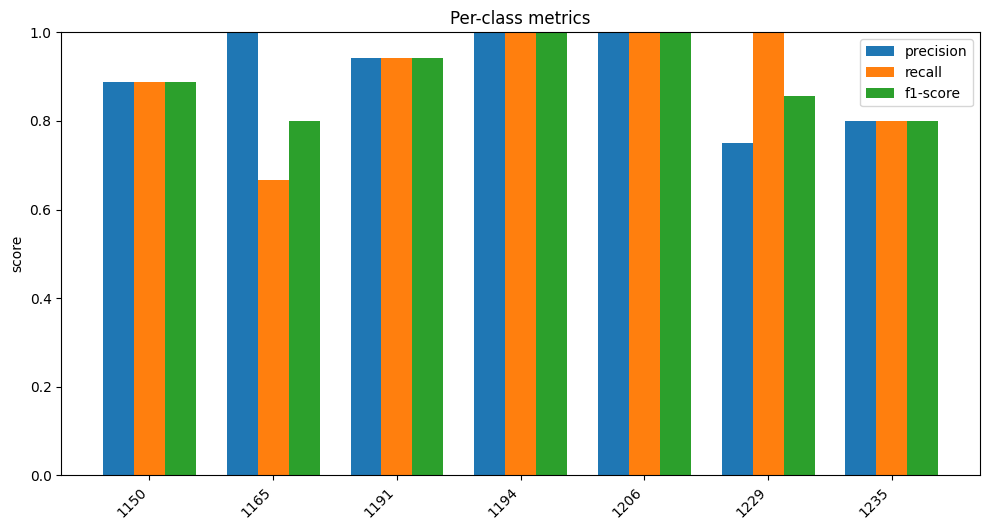

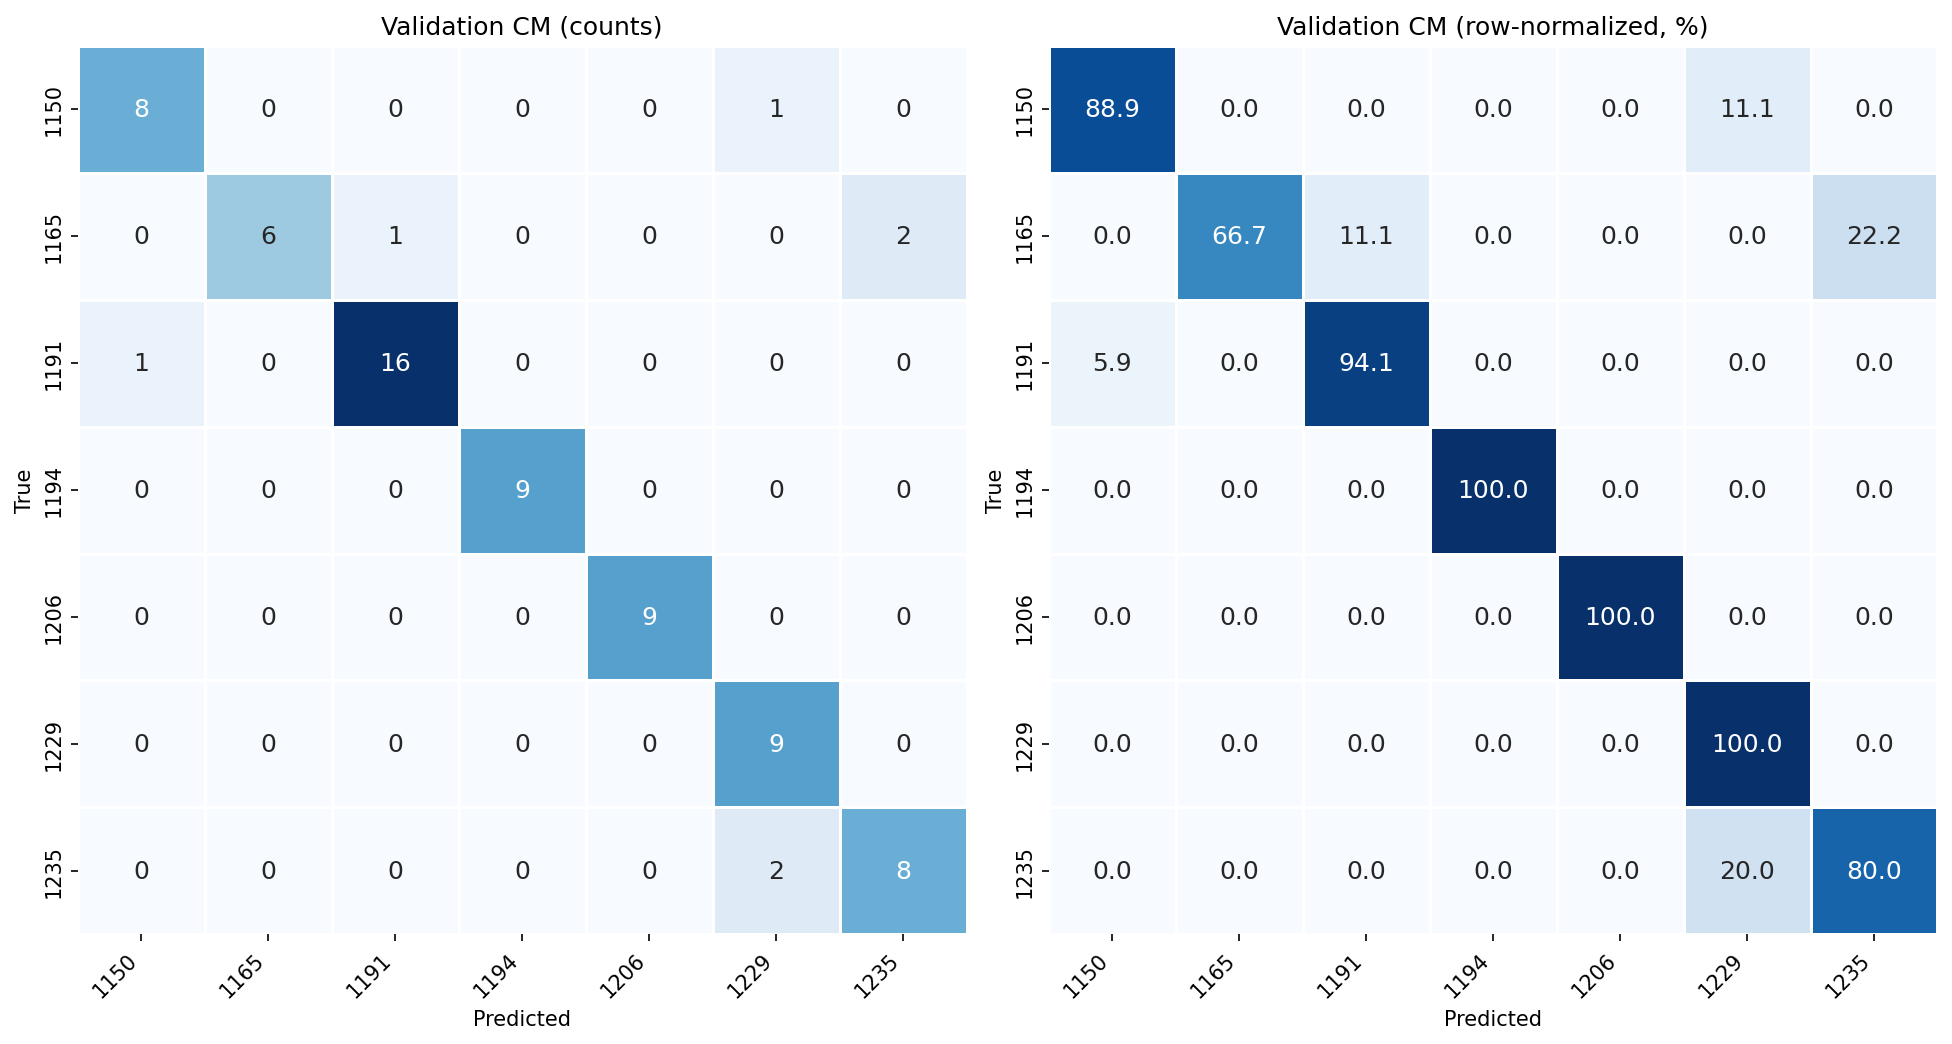

Test Accuracy: 0.7647058823529411
              precision    recall  f1-score   support

        1150       0.83      0.91      0.87        11
        1165       1.00      0.40      0.57        10
        1191       0.88      0.71      0.79        21
        1194       0.83      1.00      0.91        10
        1206       0.91      0.91      0.91        11
        1229       0.46      1.00      0.63        11
        1235       1.00      0.45      0.62        11

    accuracy                           0.76        85
   macro avg       0.85      0.77      0.76        85
weighted avg       0.85      0.76      0.76        85

Saved confusion matrices to figs/cnn_cm_test.png


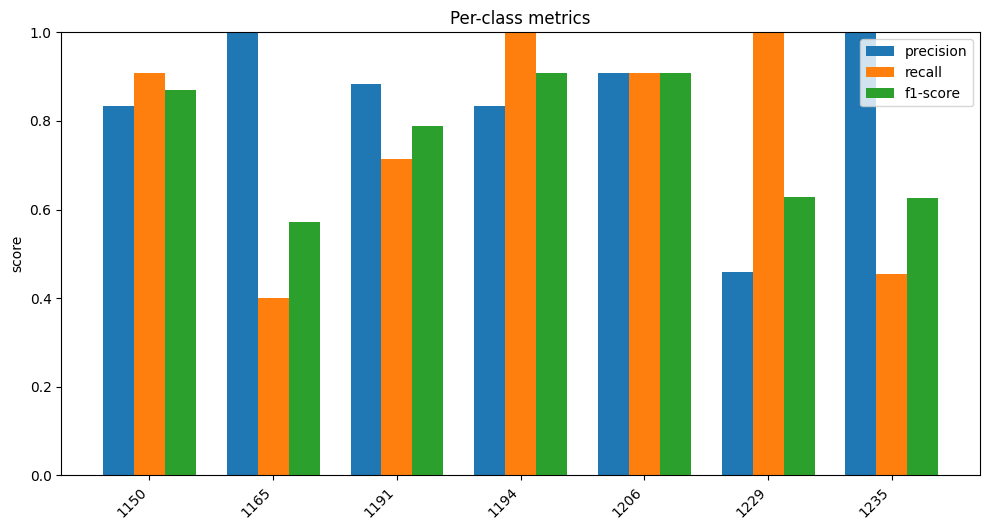

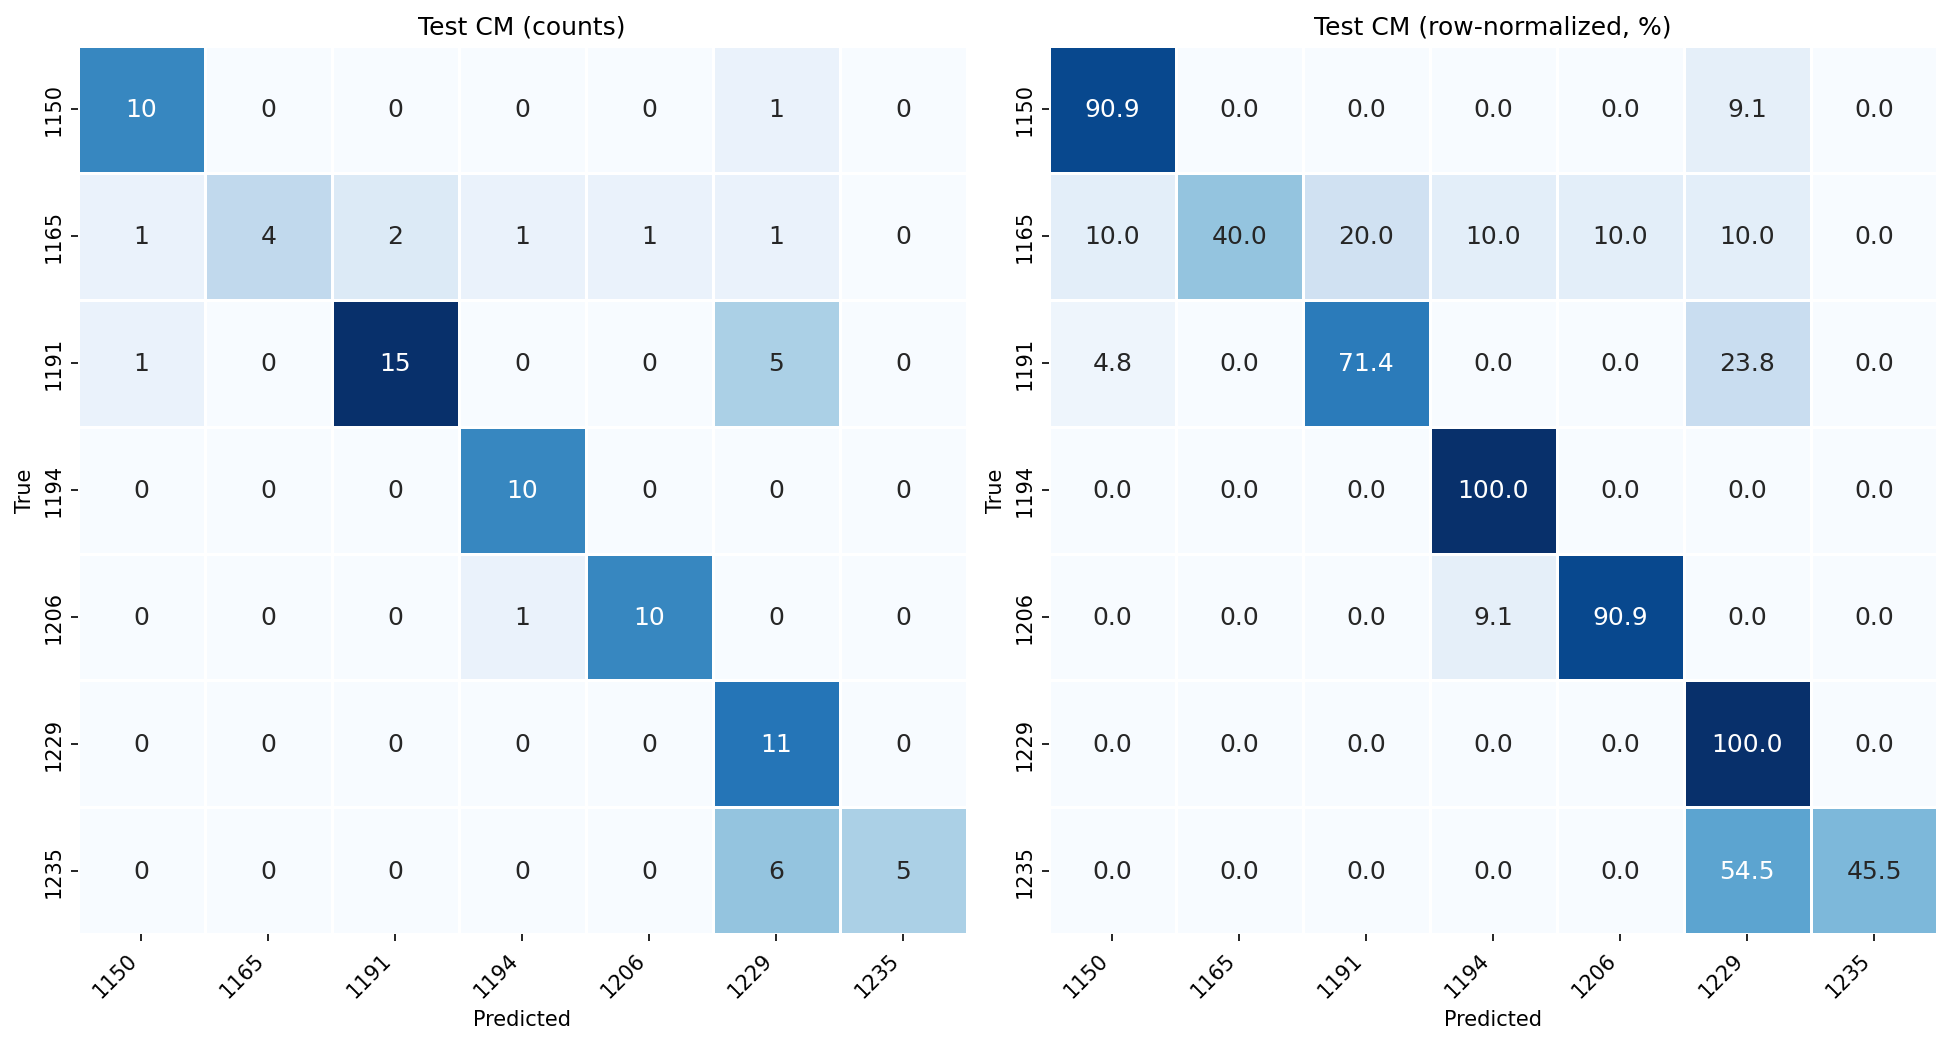

In [13]:
import os
import seaborn as sns
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

# Validation report

val_acc, y_true_val, y_pred_val, *_ = evaluate(val_loader)
print("Validation Accuracy:", val_acc)

cls = np.array(classes)
y_true_val_n = cls[np.asarray(y_true_val)]
y_pred_val_n = cls[np.asarray(y_pred_val)]
# classification report
print(classification_report(y_true_val, y_pred_val, target_names=classes))

#class-wise metrics and confusion matrices
plot_per_class_report(y_true_val_n, y_pred_val_n, classes)
plot_confusion_matrices(y_true_val_n, y_pred_val_n,
                        savepath="figs/cnn_cm_val.png",
                        title_prefix="Validation CM")

# Test report

test_acc, y_true_test, y_pred_test, *_ = evaluate(test_loader)
y_true_test_n = cls[np.asarray(y_true_test)]
y_pred_test_n = cls[np.asarray(y_pred_test)]
print("Test Accuracy:", test_acc)
# classification report
print(classification_report(y_true_test, y_pred_test, target_names=classes))


#class-wise metrics and confusion matrices
plot_per_class_report(y_true_test_n, y_pred_test_n, classes)

plot_confusion_matrices(y_true_test_n, y_pred_test_n,
                        savepath="figs/cnn_cm_test.png",
                        title_prefix="Test CM")

